                timestamp  invocations
0     2019-07-15 00:00:00         2273
1     2019-07-15 00:01:00         2267
2     2019-07-15 00:02:00         2249
3     2019-07-15 00:03:00         2334
4     2019-07-15 00:04:00         2225
...                   ...          ...
20155 2019-07-28 23:55:00         2094
20156 2019-07-28 23:56:00         2220
20157 2019-07-28 23:57:00         2038
20158 2019-07-28 23:58:00         2179
20159 2019-07-28 23:59:00         1993

[20160 rows x 2 columns]


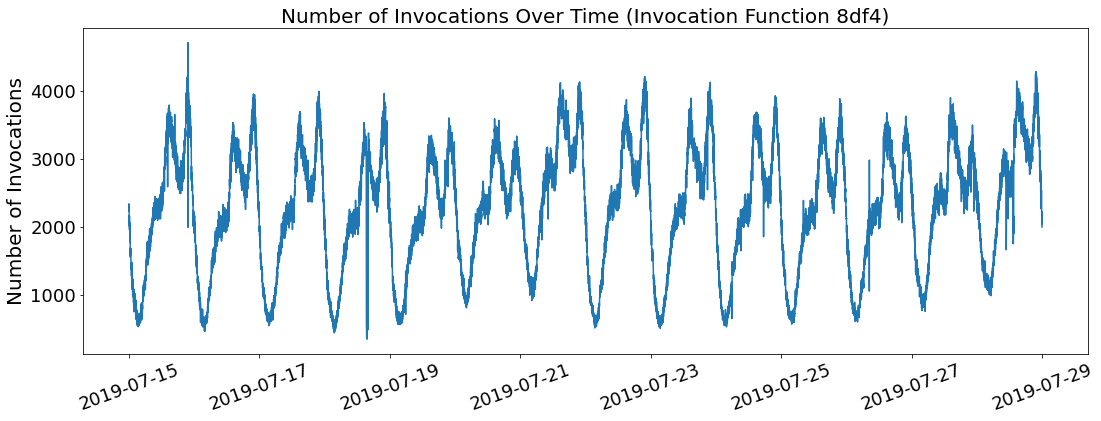

In [1]:
import warnings
warnings.filterwarnings("ignore")  # Hide some warnings for clarity

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


# Load the uploaded CSV file
file_path = 'merged_filtered_data.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Ensure the timestamp column is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Group by the timestamp and sum the invocations for the same time
df_grouped = df.groupby('timestamp', as_index=False).sum()

# Display the grouped data for the user
df_grouped.reset_index(drop=True, inplace=True)
df_grouped.head()

df=df_grouped

print(df_grouped)

# Display the processed data
# import ace_tools as tools; tools.display_dataframe_to_user(name="Grouped Invocations by Timestamp", dataframe=df_grouped)

# Plot
plt.figure(figsize=(18, 6))
plt.plot(df_grouped['timestamp'], df_grouped['invocations'])
plt.title('Number of Invocations Over Time (Invocation Function 8df4)', fontsize=20)
# plt.xlabel('Time', fontsize=20)
plt.ylabel('Number of Invocations', fontsize=20)
plt.xticks(fontsize=18, rotation=20)
plt.yticks(fontsize=18)
plt.show()


In [2]:
df.columns

Index(['timestamp', 'invocations'], dtype='object')

                timestamp  invocations  invocations_scaled
0     2019-07-15 00:00:00         2273                  24
1     2019-07-15 00:01:00         2267                  24
2     2019-07-15 00:02:00         2249                  24
3     2019-07-15 00:03:00         2334                  24
4     2019-07-15 00:04:00         2225                  24
...                   ...          ...                 ...
20155 2019-07-28 23:55:00         2094                  16
20156 2019-07-28 23:56:00         2220                  24
20157 2019-07-28 23:57:00         2038                  16
20158 2019-07-28 23:58:00         2179                  24
20159 2019-07-28 23:59:00         1993                  16

[20160 rows x 3 columns]


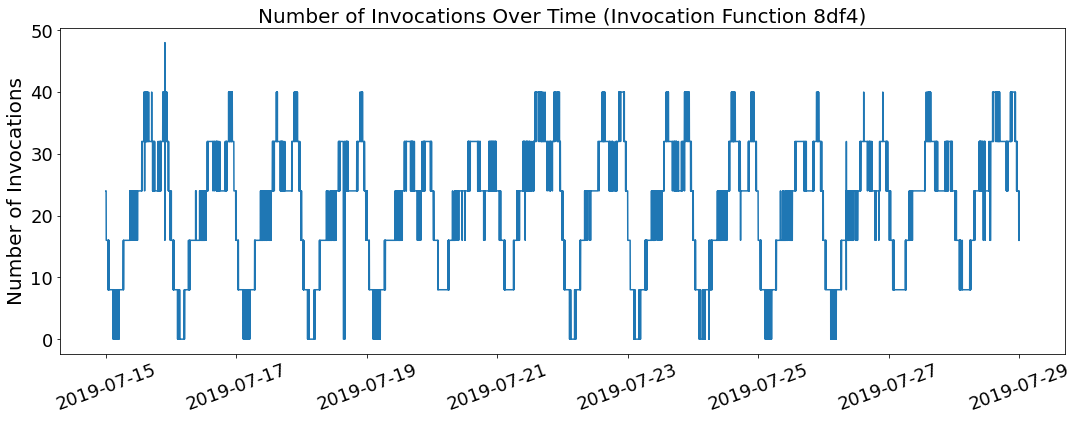

In [3]:
# Normalize 'invocations' to a range of [0, 50] and convert to integer
# df['invocations_scaled'] = ((df['invocations'] - df['invocations'].min()) / 
#                             (df['invocations'].max() - df['invocations'].min()) * 50).astype(int)

#only odd number
# df['invocations_scaled'] = (((df['invocations'] - df['invocations'].min()) / 
#                              (df['invocations'].max() - df['invocations'].min()) * 24)
#                              .round().astype(int) * 2 + 1)
# /4
# df['invocations_scaled'] = (((df['invocations'] - df['invocations'].min()) / 
#                              (df['invocations'].max() - df['invocations'].min()) * 12)
#                              .round().astype(int) * 4)

#8
df['invocations_scaled'] = (((df['invocations'] - df['invocations'].min()) / 
                             (df['invocations'].max() - df['invocations'].min()) * 6)
                             .round().astype(int) * 8)


print(df)

# Plot
plt.figure(figsize=(18, 6))
plt.plot(df['timestamp'], df['invocations_scaled'])
plt.title('Number of Invocations Over Time (Invocation Function 8df4)', fontsize=20)
# plt.xlabel('Time', fontsize=20)
plt.ylabel('Number of Invocations', fontsize=20)
plt.xticks(fontsize=18, rotation=20)
plt.yticks(fontsize=18)
plt.show()


               timestamp  invocations  invocations_scaled
0    2019-07-15 00:00:00         2273                  24
1    2019-07-15 00:01:00         2267                  24
2    2019-07-15 00:02:00         2249                  24
3    2019-07-15 00:03:00         2334                  24
4    2019-07-15 00:04:00         2225                  24
...                  ...          ...                 ...
1435 2019-07-15 23:55:00         1937                  16
1436 2019-07-15 23:56:00         2038                  16
1437 2019-07-15 23:57:00         2024                  16
1438 2019-07-15 23:58:00         2042                  16
1439 2019-07-15 23:59:00         2023                  16

[1440 rows x 3 columns]


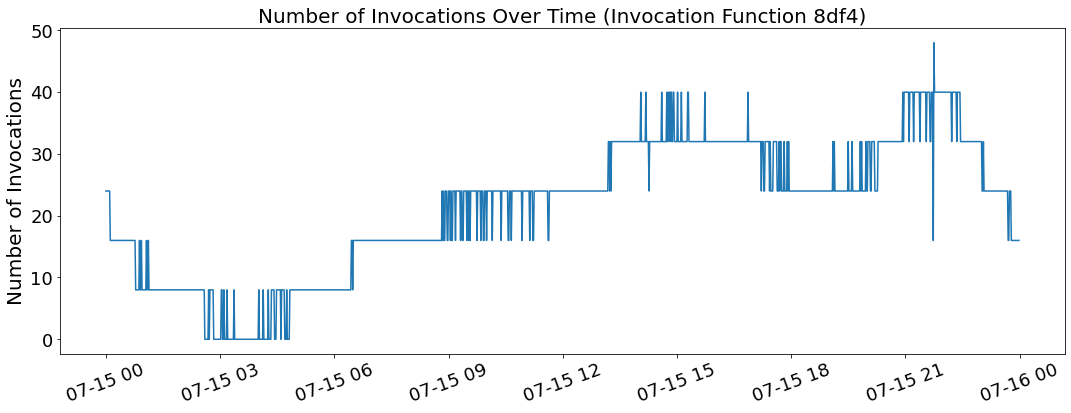

In [4]:
# Filter for a single day (e.g., the first day available in the dataset)
df_day = df.head(1440)
print(df_day)

# Plot
plt.figure(figsize=(18, 6))
plt.plot(df_day['timestamp'], df_day['invocations_scaled'])
plt.title('Number of Invocations Over Time (Invocation Function 8df4)', fontsize=20)
# plt.xlabel('Time', fontsize=20)
plt.ylabel('Number of Invocations', fontsize=20)
plt.xticks(fontsize=18, rotation=20)
plt.yticks(fontsize=18)
plt.show()

         5_min_interval  invocations_scaled
0   2019-07-15 00:00:00                  21
1   2019-07-15 00:10:00                  16
2   2019-07-15 00:20:00                  16
3   2019-07-15 00:30:00                  16
4   2019-07-15 00:40:00                  13
..                  ...                 ...
139 2019-07-15 23:10:00                  24
140 2019-07-15 23:20:00                  24
141 2019-07-15 23:30:00                  24
142 2019-07-15 23:40:00                  20
143 2019-07-15 23:50:00                  16

[144 rows x 2 columns]


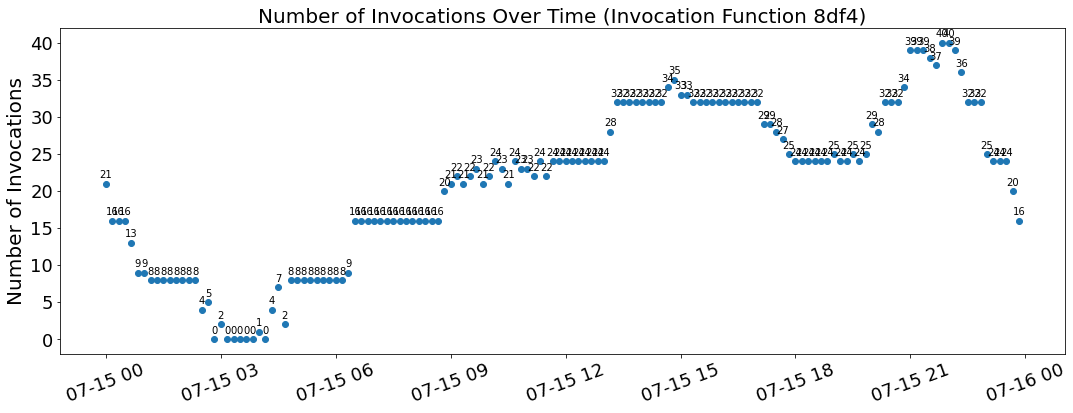

In [5]:
# Group by each minute and take the average
df_first_day = df_day
df_first_day['minute'] = df_first_day['timestamp'].dt.strftime('%Y-%m-%d %H:%M')
# df_first_day['5_min_interval'] = df_first_day['timestamp'].dt.floor('5T')
# df_avg_per_5min = df_first_day.groupby('5_min_interval', as_index=False)['invocations_scaled'].mean()
df_first_day['5_min_interval'] = df_first_day['timestamp'].dt.floor('10T')
df_avg_per_5min = df_first_day.groupby('5_min_interval', as_index=False)['invocations_scaled'].mean()
df_avg_per_5min['invocations_scaled'] = df_avg_per_5min['invocations_scaled'].astype(int)

# Convert back to datetime for plotting
# df_avg_per_min['5_min_interval'] = pd.to_datetime(df_avg_per_min['5_min_interval'])
print(df_avg_per_5min)

# Plot
plt.figure(figsize=(18, 6))
plt.scatter(df_avg_per_5min['5_min_interval'], df_avg_per_5min['invocations_scaled'])

# Add text labels at each point
for x, y in zip(df_avg_per_5min['5_min_interval'], df_avg_per_5min['invocations_scaled']):
    plt.text(x, y + 0.5, str(y), ha='center', va='bottom', fontsize=10)  # Adjust y + 0.5 for better spacing

plt.title('Number of Invocations Over Time (Invocation Function 8df4)', fontsize=20)
# plt.xlabel('Time', fontsize=20)
plt.ylabel('Number of Invocations', fontsize=20)
plt.xticks(fontsize=18, rotation=20)
plt.yticks(fontsize=18)
plt.show()


In [6]:
import warnings
warnings.filterwarnings("ignore")  # Hide some warnings for clarity

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Statsmodels (ARIMA)
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet
from prophet import Prophet

# XGBoost
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# TensorFlow (LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import itertools
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.stattools import adfuller

# -----------------------
# 2. Utility Functions
# -----------------------
def mean_absolute_percentage_error(y_true, y_pred):
    """Compute MAPE as a percentage."""
    # Avoid division by zero by adding a small epsilon
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

def create_lag_features(df, target_col="invocations", lags=[1,2,3]):
    """Create lag features for XGBoost or other ML models."""
    df_lag = df.copy()
    for lag in lags:
        df_lag[f"lag_{lag}"] = df_lag[target_col].shift(lag)
    df_lag.dropna(inplace=True)
    return df_lag

def create_lstm_dataset(series, window_size=3):
    """Transform a 1D array into (X, y) pairs for an LSTM."""
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

# -----------------------
# 3. Main Script
# -----------------------
def main():

    # Step B: Load data
    # Load the uploaded CSV file
    file_path = 'merged_filtered_data.csv'
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)
    
    # Ensure the timestamp column is in datetime format
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Group by the timestamp and sum the invocations for the same time
    df_grouped = df.groupby('timestamp', as_index=False).sum()
    df_grouped = df_grouped[['timestamp', 'invocations']]
    
    # Display the grouped data for the user
    df_grouped.reset_index(drop=True, inplace=True)
    df_grouped.head()

    df = df_grouped
    
    
    # We have ~336 rows (14 days * 24 hours)
    # We'll split the last 24 hours for testing.
    split_point = df.index[-2880]  # start of the last day
    df_train = df.loc[:split_point]
    df_test = df.loc[split_point:]
    
    print("[INFO] Train size:", len(df_train), "Test size:", len(df_test))
    
    # Dictionary to store (MSE, MAPE) and predictions
    results = {}
    
    # ------------------------------------------------
    # 3.1 ARIMA (using SARIMAX as ARIMA)
    # ------------------------------------------------
    # We'll do a simple ARIMA(1,1,1). 
    # arima_model = SARIMAX(
    #     df_train["invocations"], 
    #     order=(1,1,1),
    #     enforce_stationarity=False,
    #     enforce_invertibility=False
    # )
    # arima_results = arima_model.fit(disp=False)

    
    #fine-tune
    # df["seasonal_diff"] = df["invocations"].diff(1440).dropna()
    # adf_test = adfuller(df["seasonal_diff"].dropna())
    # print(f"ADF Statistic: {adf_test[0]}, p-value: {adf_test[1]}")
    # df_train_diff = df_train["invocations"].diff(1440).dropna()
    # plot_acf(df_train_diff, lags=100)
    # plot_pacf(df_train_diff, lags=40)

    arima_model = SARIMAX(
        df_train["invocations"], 
        order=(1,1,1),
        seasonal_order=(1,1,1,1440),  # seasonal parameters
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    arima_results = arima_model.fit(disp=False)
    
    n_test = len(df_test)
    arima_forecast = arima_results.forecast(steps=n_test)
    
    # Compute errors
    arima_mse = mean_squared_error(df_test["invocations"], arima_forecast)
    arima_mape = mean_absolute_percentage_error(df_test["invocations"], arima_forecast)
    results["ARIMA"] = (arima_mse, arima_mape, arima_forecast)

    # ------------------------------------------------
    # 3.2 Prophet
    # ------------------------------------------------
    # Prophet expects columns: ds, y
    df_prophet_train = df_train.reset_index().rename(columns={"timestamp":"ds", "invocations":"y"})
    df_prophet_test = df_test.reset_index().rename(columns={"timestamp":"ds", "invocations":"y"})
    
    prophet_model = Prophet(daily_seasonality=True)
    # prophet_model = Prophet(daily_seasonality=False)  # Disable default daily seasonality
    # prophet_model.add_seasonality(name='hourly', period=60, fourier_order=6)  # Add hourly seasonality
    # prophet_model.add_seasonality(name='daily', period=1440, fourier_order=12)  # Add daily seasonality
    # prophet_model.add_seasonality(name='weekly', period=10080, fourier_order=6)  # Optional: Weekly seasonality

    prophet_model.fit(df_prophet_train)

    # future = prophet_model.make_future_dataframe(periods=n_test, freq='H')
    future = prophet_model.make_future_dataframe(periods=n_test, freq='T')
    prophet_forecast_df = prophet_model.predict(future)
    prophet_forecast = prophet_forecast_df.tail(n_test)["yhat"].values  # last 24 predictions
    
    prophet_mse = mean_squared_error(df_prophet_test["y"], prophet_forecast)
    prophet_mape = mean_absolute_percentage_error(df_prophet_test["y"], prophet_forecast)
    results["Prophet"] = (prophet_mse, prophet_mape, prophet_forecast)

    # # ------------------------------------------------
    # # 3.3 XGBoost
    # # ------------------------------------------------
    # df_lag = create_lag_features(df, target_col="invocations", lags=[1,2,3])
    # df_lag_train = df_lag.loc[:split_point].dropna()
    # df_lag_test = df_lag.loc[split_point:].dropna()
    
    # X_train = df_lag_train.drop("invocations", axis=1)
    # y_train = df_lag_train["invocations"]
    # X_test = df_lag_test.drop("invocations", axis=1)
    # y_test = df_lag_test["invocations"]
    
    # dtrain = xgb.DMatrix(X_train, label=y_train)
    # dtest = xgb.DMatrix(X_test, label=y_test)
    
    # params = {
    #     "objective": "reg:squarederror",
    #     "max_depth": 3,
    #     "eta": 0.1,
    #     "seed": 42
    # }
    # xgb_model = xgb.train(params, dtrain, num_boost_round=100)
    # xgb_preds = xgb_model.predict(dtest)
    
    # xgb_mse = mean_squared_error(y_test, xgb_preds)
    # xgb_mape = mean_absolute_percentage_error(y_test, xgb_preds)
    # results["XGBoost"] = (xgb_mse, xgb_mape, xgb_preds)

    # ------------------------------------------------
    # 3.4 LSTM
    # ------------------------------------------------
    values = df["invocations"].values
    train_values = values[:len(df_train)]
    test_values = values[len(df_train):]  # last 24 points
    
    window_size = 10
    X_train_lstm, y_train_lstm = create_lstm_dataset(train_values, window_size)
    X_test_lstm, y_test_lstm = create_lstm_dataset(test_values, window_size)
    
    # Reshape for LSTM: (samples, timesteps, features=1)
    X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
    X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))
    
    lstm_model = Sequential()
    lstm_model.add(LSTM(32, activation='relu', input_shape=(window_size, 1)))
    lstm_model.add(Dense(1))
    lstm_model.compile(optimizer='adam', loss='mse')
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lstm_model.fit(
        X_train_lstm, y_train_lstm,
        validation_split=0.2,
        epochs=50,
        batch_size=16,
        callbacks=[early_stopping],
        verbose=0
    )
    
    lstm_preds = lstm_model.predict(X_test_lstm).flatten()
    lstm_mse = mean_squared_error(y_test_lstm, lstm_preds)
    lstm_mape = mean_absolute_percentage_error(y_test_lstm, lstm_preds)
    results["LSTM"] = (lstm_mse, lstm_mape, lstm_preds)

    # -----------------------
    # 4. Evaluate & Plot
    # -----------------------
    print("\n=== Model Evaluation on Test Set ===")
    print("Metrics: MSE (lower is better), MAPE% (lower is better)\n")
    for model_name, (mse_val, mape_val, _) in results.items():
        print(f"{model_name}: MSE={mse_val:.2f}, MAPE={mape_val:.2f}%")
    
    # Create columns in df_test to store predictions
    df_test_plot = df_test.copy()
    df_test_plot["ARIMA"] = np.nan
    df_test_plot["Prophet"] = np.nan
    # df_test_plot["XGBoost"] = np.nan
    df_test_plot["LSTM"] = np.nan
    
    # 4.1 ARIMA: index should match test index if we set it that way
    arima_forecast = results["ARIMA"][2]
    print(len(arima_forecast))
    arima_forecast.index = df_test_plot.index  # align the ARIMA forecast index
    df_test_plot["ARIMA"] = arima_forecast
    
    # # 4.2 Prophet: we have an array, same length as test, so just assign
    prophet_forecast = results["Prophet"][2]
    df_test_plot["Prophet"] = prophet_forecast
    
    # # 4.3 XGBoost: predictions correspond to df_lag_test.index
    # xgb_preds = results["XGBoost"][2]
    # df_test_plot.loc[df_lag_test.index, "XGBoost"] = xgb_preds
    
    # 4.4 LSTM: we lose the first 'window_size' points in test due to the sliding window
    print(len(results["LSTM"]))
    lstm_preds = results["LSTM"][2]
    print(len(lstm_preds))
    # The LSTM predictions correspond to the last (n_test - window_size) timestamps
    # So we align them to the last (n_test - window_size) rows of df_test_plot
    df_test_plot["LSTM"] = np.nan
    # E.g. if we have 24 test points, we get 21 predictions for window_size=3
    df_test_plot.iloc[-len(lstm_preds):, df_test_plot.columns.get_loc("LSTM")] = lstm_preds
    
    # Plot everything
    plt.figure(figsize=(10, 6))
    plt.plot(df_test_plot.index, df_test_plot["invocations"], label="Ground Truth", color='black', linewidth=2)
    plt.plot(df_test_plot.index, df_test_plot["ARIMA"], label="ARIMA")
    plt.plot(df_test_plot.index, df_test_plot["Prophet"], label="Prophet")
    # plt.plot(df_test_plot.index, df_test_plot["XGBoost"], label="XGBoost")
    plt.plot(df_test_plot.index, df_test_plot["LSTM"], label="LSTM")
    plt.title("Test Set: Predictions vs. Ground Truth")
    plt.xlabel("Timestamp")
    plt.ylabel("invocations")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n[INFO] Plot displayed. Script complete!")

if __name__ == "__main__":
    main()


ModuleNotFoundError: No module named 'prophet'

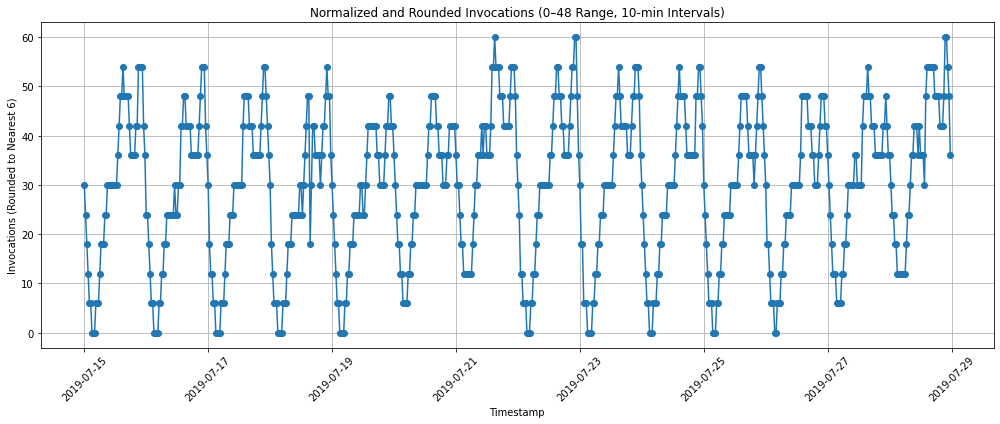

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("merged_filtered_data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Resample to 10-minute intervals and sum invocations
df_agg = df['invocations'].resample('10T').sum().astype(int)

# # Smooth using rolling mean
smoothed = df_agg.rolling(window=3, min_periods=1).mean()
# smoothed = df_agg

# Round to nearest multiple of 6
smoothed_rounded = (smoothed / 6).round() * 6
smoothed_rounded = smoothed_rounded.astype(int)

# Filter to include only timestamps where minute is a multiple of 6
smoothed_filtered = smoothed_rounded[smoothed_rounded.index.minute % 6 == 0]

# Normalize to range [0, 48]
min_val = smoothed_filtered.min()
max_val = smoothed_filtered.max()
normalized_invocations = 60 * (smoothed_filtered - min_val) / (max_val - min_val)

# Round to nearest multiple of 6
normalized_invocations_rounded = (normalized_invocations / 6).round() * 6
normalized_invocations_rounded = normalized_invocations_rounded.astype(int)

# Create final DataFrame
final_df = normalized_invocations_rounded.reset_index()
final_df.columns = ['timestamp', 'invocations']

# Save to CSV
final_df.to_csv("final_normalized_invocations.csv", index=False)

# Plot the result
plt.figure(figsize=(14, 6))
plt.plot(final_df['timestamp'], final_df['invocations'], marker='o', linestyle='-', linewidth=1.5)
plt.title('Normalized and Rounded Invocations (0–48 Range, 10-min Intervals)')
plt.xlabel('Timestamp')
plt.ylabel('Invocations (Rounded to Nearest 6)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()